# ROSMAP PCC : repeat-count DESeq2 with a 2-level TDP-43 split

In [ ]:
# === 0. Setup =================================================================
options(warn = 1, scipen = 6, stringsAsFactors = FALSE)
t_start <- Sys.time()
log_msg <- function(msg) cat(sprintf("[%s] %s\n", format(Sys.time()), msg))
log_msg("=== ROSMAP PCC TDP-split pipeline starting ===")

In [1]:
suppressPackageStartupMessages({
  library(tidyverse)
  library(here)
  library(powerjoin)
  library(qs)
  library(DESeq2)
  library(ashr)
  library(broom)
  library(broom.mixed)
  library(BiocParallel)
  library(RhpcBLASctl)
  library(conflicted)
  library(ggrepel)
  library(ggbeeswarm)
  library(ggnewscale)
  library(ggh4x)
  library(ggrastr)
  library(emmeans)
  library(pheatmap)
})

In [2]:
conflicts_prefer(
  dplyr::count, dplyr::filter, dplyr::select, dplyr::summarise,
  dplyr::mutate, dplyr::rename, dplyr::lag, dplyr::first, dplyr::last,
  dplyr::between, dplyr::slice, dplyr::collapse, dplyr::desc,
  dplyr::union, dplyr::intersect, dplyr::setdiff,
  .quiet = TRUE
)

In [3]:
# === 1. Paths and output directory ============================================
META_PATH       <- "rosmap_metadata.csv"
CLASSIF_PATH    <- "rosmap_classification.csv"
RM_RAW_PATH     <- "/n/scratch/users/r/rob6090/projects/tdp-43/scripts/analysis/final_dsRNA/repeatmasker_raw.csv"
REPEAT_QS_PATH  <- "amp-ad_repeat_counts_raw-fraction_AND_secondary_noMETA.qs"

In [4]:
OUT_DIR     <- "results_rosmap_pcc_tdp_split"
PLOTS_DIR   <- file.path(OUT_DIR, "plots")
FAMILY_DIR  <- file.path(OUT_DIR, "per_family")
VOLCANO_DIR <- file.path(PLOTS_DIR, "volcanoes")

In [ ]:
for (d in c(OUT_DIR, PLOTS_DIR, FAMILY_DIR, VOLCANO_DIR)) {
  dir.create(d, showWarnings = FALSE, recursive = TRUE)
}
log_msg(sprintf("All outputs will be written under %s/", OUT_DIR))

In [ ]:
# === 2. Load inputs ===========================================================
log_msg("Loading inputs ...")
rosmap_meta_raw      <- read_csv(META_PATH,    show_col_types = FALSE)
classif              <- read_csv(CLASSIF_PATH, show_col_types = FALSE)
rm_raw               <- read_csv(RM_RAW_PATH,  show_col_types = FALSE)
rosmap_repeat_counts <- qread(REPEAT_QS_PATH)
log_msg(sprintf("rm_raw rows = %d ; count matrix = %d x %d",
                nrow(rm_raw),
                nrow(rosmap_repeat_counts$counts),
                ncol(rosmap_repeat_counts$counts)))

In [ ]:
# === 3. Build pcc_meta with TDP-43 split based on class_high ==================
# No diagnosis filter; every PCC sample with a valid TDP-43 call is kept.
log_msg("Building pcc_meta — TDP+ vs TDP- (cryptic-exon-based) ...")
pcc_meta <- rosmap_meta_raw %>%
  filter(brain_region == "PCC") %>%
  power_inner_join(
    classif %>% select(specimenID, n_expressed, class_low, class_high),
    by = c("sample_id" = "specimenID"),
    check = check_specs(unmatched_keys_left = "warn",
                        duplicate_keys_right = "warn")
  ) %>%
  mutate(
    tdp43_status = factor(
      if_else(class_high == "positive", "TDPpos", "TDPneg"),
      levels = c("TDPneg", "TDPpos")
    ),
    tdp43_status_low = factor(
      if_else(class_low == "positive", "TDPpos", "TDPneg"),
      levels = c("TDPneg", "TDPpos")
    ),
    sex             = factor(sex),
    sequencingBatch = factor(sequencingBatch),
    Study           = factor(Study),
    age_death_num   = as.numeric(age_death_num),
    rin             = as.numeric(rin),
    #apoe4_count     = as.numeric(apoe4_count)
  ) %>%
  drop_na(tdp43_status, rin, age_death_num,
          sex, sequencingBatch)
 
log_msg(sprintf("pcc_meta rows = %d", nrow(pcc_meta)))
log_msg("TDP-43 status counts:")
print(pcc_meta %>% dplyr::count(tdp43_status))
log_msg("TDP-43 × diagnosis cross-tab:")
print(pcc_meta %>% dplyr::count(tdp43_status, diagnosis))

In [ ]:
 
write_csv(pcc_meta, file.path(OUT_DIR, "pcc_meta_tdp_split.csv"))

In [13]:
head(pcc_meta)

sample_id,individualID,projid,Study,diagnosis,sex,age_death,age_death_num,pmi,braak,⋯,brain_region,tissue,organ,matched_specimen,is_replicate_id,n_expressed,class_low,class_high,tdp43_status,tdp43_status_low
<chr>,<chr>,<chr>,<fct>,<chr>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<lgl>,<dbl>,<chr>,<chr>,<fct>,<fct>
1012-PCC,R9798367,51791453,MAP,MCI,F,86.529774127310063,86.52977,5.700000,4,⋯,PCC,posterior cingulate cortex,brain,Sample_1012-PCC,FALSE,0,negative,negative,TDPneg,TDPneg
1051-PCC,R5691943,69924281,MAP,AD,F,87.389459274469544,87.38946,6.466667,5,⋯,PCC,posterior cingulate cortex,brain,Sample_1051-PCC,FALSE,1,positive,negative,TDPneg,TDPpos
1089r-PCC,R9677385,68539908,MAP,Control,M,81.314168377823407,81.31417,9.583333,2,⋯,PCC,posterior cingulate cortex,brain,Sample_1089r-PCC,TRUE,1,positive,negative,TDPneg,TDPpos
2000r-PCC,R7310856,73146926,MAP,MCI,F,84.331279945242983,84.33128,12.666667,5,⋯,PCC,posterior cingulate cortex,brain,Sample_2000r-PCC,TRUE,0,negative,negative,TDPneg,TDPneg
2002r-PCC,R7418040,65214844,MAP,AD,F,86.32443531827515,86.32444,16.750000,2,⋯,PCC,posterior cingulate cortex,brain,Sample_2002r-PCC,TRUE,0,negative,negative,TDPneg,TDPneg
2003r-PCC,R7577991,98322204,MAP,AD,M,90+,90.00000,5.050000,5,⋯,PCC,posterior cingulate cortex,brain,Sample_2003r-PCC,TRUE,2,positive,positive,TDPpos,TDPpos


In [ ]:
# === 4. Align count matrix to sample table ====================================
log_msg("Aligning count matrix to pcc_meta ...")
repeat_counts_mat <- rosmap_repeat_counts[["counts"]]
colnames(repeat_counts_mat) <- str_remove(colnames(repeat_counts_mat),
                                          fixed(".final.bam"))
 
common_ids <- intersect(colnames(repeat_counts_mat), pcc_meta$sample_id)
pcc_meta   <- pcc_meta %>%
  filter(sample_id %in% common_ids) %>%
  arrange(match(sample_id, common_ids))
 
repeat_counts_mat <- repeat_counts_mat[, pcc_meta$sample_id]
repeat_counts_int <- round(repeat_counts_mat)
stopifnot(identical(colnames(repeat_counts_int), pcc_meta$sample_id))
log_msg(sprintf("After realignment: %d features x %d samples",
                nrow(repeat_counts_int), ncol(repeat_counts_int)))

In [ ]:
# === 5. Restrict to 11 canonical repeat families ==============================
log_msg("Filtering to 11 canonical families ...")
keep_families <- c(
  "SINE/Alu", "SINE/MIR", "SINE/tRNA",
  "LINE/L1",  "LINE/L2",
  "LTR",      "LTR/ERV1", "LTR/ERVK", "LTR/ERVL", "LTR/ERVL-MaLR",
  "Retroposon/SVA"
)
stopifnot(nrow(repeat_counts_int) == nrow(rm_raw))
 
keep_rows         <- which(rm_raw$class_family %in% keep_families)
rm_raw            <- rm_raw[keep_rows, ]
repeat_counts_int <- repeat_counts_int[keep_rows, ]
log_msg(sprintf("After family filter: %d features x %d samples",
                nrow(repeat_counts_int), ncol(repeat_counts_int)))
print(rm_raw %>% dplyr::count(class_family) %>% arrange(desc(n)))

In [ ]:
 
write_csv(rm_raw, file.path(OUT_DIR, "rm_raw_11_families.csv"))

In [11]:
# === 6. Build DESeq2 object ===================================================
log_msg("Building DESeqDataSet ...")
de_coldata <- pcc_meta %>%
  column_to_rownames("sample_id") %>%
  select(tdp43_status, age_death_num, sex, rin,
         sequencingBatch, Study) %>%
  mutate(across(c(age_death_num, rin), \(x) as.numeric(scale(x))))

[2026-05-17 14:53:07] Building DESeqDataSet ...


In [18]:
 
dds <- DESeqDataSetFromMatrix(
  countData = repeat_counts_int,
  colData   = de_coldata,
  design    = ~ age_death_num + sex + rin + sequencingBatch + Study +
                tdp43_status
)

converting counts to integer mode



In [12]:
gene_counts <- qread("rosmap_pcc_gene_counts.qs")

In [22]:
rosmap_size_factors <- DESeq2::estimateSizeFactorsForMatrix(round(gene_counts))
sizeFactors(dds) <- rosmap_size_factors[colnames(dds)]

In [23]:
print(summary(sizeFactors(dds)))

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.3785  0.9292  1.0189  1.0240  1.1068  1.5166 


In [24]:
pdf(file.path(PLOTS_DIR, "size_factors_vs_libsize.pdf"), width = 6, height = 5)
plot(sizeFactors(dds), colSums(counts(dds)),
     xlab = "Size factor", ylab = "Library size (total counts)",
     pch = 16, col = "grey30")
dev.off()

agg_record_1125107346 
                    2

In [13]:
# === 8. Free upstream objects =================================================
rm(classif, rosmap_meta_raw, rosmap_repeat_counts,
   repeat_counts_mat, repeat_counts_int)
gc(full = TRUE)
 

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,11136575,594.8,33620335,1795.6,18616371,994.3
Vcells,113631990,867.0,9641256237,73557.0,10073590572,76855.4


In [ ]:
oso <- sapply(ls(), function(x) object.size(get(x, envir = .GlobalEnv)))
log_msg("Top in-memory objects:")
print(sort(oso, decreasing = TRUE)[1:10] |> format(units = "GB", standard = "SI"))
 
qsave(dds, file.path(OUT_DIR, "dds_pre_deseq.qs"),
      nthreads = 4, preset = "fast")
log_msg("Saved pre-DESeq dds checkpoint")

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,15175275,810.5,33643747,1796.8,20833414,1112.7
Vcells,1092554803,8335.6,11569589360,88269.0,14154764286,107992.3


[2026-05-16 18:15:10] Top in-memory objects:
                dds              rm_raw         gene_counts           keep_rows 
       "8307483104"        " 759631912"        " 159478192"        "  15846296" 
           pcc_meta          de_coldata rosmap_size_factors          common_ids 
       "    276056"        "     54056"        "     39168"        "     35112" 
            log_msg       keep_families 
       "      6584"        "       856" 
[2026-05-16 18:15:18] Saved pre-DESeq dds checkpoint


In [ ]:
# === 9. Run DESeq (NO row pre-filter) =========================================
log_msg(sprintf("Starting DESeq() on %d features x %d samples (serial; no row filter) ...",
                nrow(dds), ncol(dds)))
t_d <- Sys.time()
dds <- DESeq(dds, parallel = FALSE, minReplicatesForReplace = Inf)
log_msg(sprintf("DESeq() complete in %.2f hours",
                as.numeric(difftime(Sys.time(), t_d, units = "hours"))))
 
qsave(dds, file.path(OUT_DIR, "rosmap_pcc_repeat_de_tdp_split.qs"),
      nthreads = 8, preset = "fast")
log_msg("Saved fitted dds")
print(resultsNames(dds))

In [14]:
dds <- qread("results_rosmap_pcc_tdp_split/rosmap_pcc_repeat_de_tdp_split.qs",nthreads = 8)

In [16]:
print(resultsNames(dds))

[1] "Intercept"                      "age_death_num"                 
[3] "sex_M_vs_F"                     "rin"                           
[5] "sequencingBatch_NYGC3_vs_NYGC2" "Study_ROS_vs_MAP"              
[7] "tdp43_status_TDPpos_vs_TDPneg" 


In [17]:
# === 10. Extract single TDP-43 contrast with ashr shrinkage ===================
extract_deseq_result <- function(de, contrast = NULL, name = NULL) {
  if (!is.null(name)) {
    res <- results(de, name = name)
  } else {
    res <- results(de, contrast = contrast)
  }
  shrunken <- lfcShrink(de, res = res, type = "ashr")
  shrunken %>%
    as_tibble(rownames = "gene_id") %>%
    left_join(
      res %>% as_tibble(rownames = "gene_id") %>%
        select(gene_id, log2FoldChange, lfcSE),
      by = "gene_id", suffix = c("", "_MLE")
    )
}
 
attach_family <- function(res_tbl) {
  if ("class_family" %in% colnames(res_tbl)) return(res_tbl)
  res_tbl %>%
    mutate(row_idx      = match(gene_id, rownames(dds)),
           class_family = rm_raw$class_family[row_idx],
           rep_name     = rm_raw$rep_name[row_idx]) %>%
    select(-row_idx)
}
 
log_msg("Extracting TDPpos vs TDPneg contrast with ashr shrinkage ...")
res_tdp <- extract_deseq_result(
  dds, contrast = c("tdp43_status", "TDPpos", "TDPneg")
) %>% attach_family()
 
qsave(res_tdp, file.path(OUT_DIR, "res_tdp_pos_vs_neg.qs"),
      nthreads = 8, preset = "fast")
write_csv(res_tdp, file.path(OUT_DIR, "res_tdp_pos_vs_neg.csv"))
log_msg(sprintf("Element-level contrast saved (%d rows)", nrow(res_tdp)))

[2026-05-17 15:00:45] Extracting TDPpos vs TDPneg contrast with ashr shrinkage ...


using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041



[2026-05-17 15:06:59] Element-level contrast saved (3961562 rows)


In [20]:
# === 11. Build per-family element-level long tibbles ==========================
log_msg("Building per-family element-level long tibbles ...")
target_families <- keep_families
family_idx_list <- split(seq_len(nrow(dds)), rm_raw$class_family)
 
norm_full <- counts(dds, normalized = TRUE)
raw_full  <- counts(dds, normalized = FALSE)
 
for (fam in target_families) {
  safe <- gsub("/", "_", fam)
  idx  <- family_idx_list[[fam]]
  if (length(idx) == 0) {
    log_msg(sprintf("  %s: 0 elements — skipped", fam)); next
  }
  log_msg(sprintf("  %s: %d elements", fam, length(idx)))
 
  fam_norm_mat <- norm_full[idx, , drop = FALSE]
  fam_raw_mat  <- raw_full [idx, , drop = FALSE]
 
  fam_long <-
    as_tibble(fam_norm_mat, rownames = "gene_id") %>%
    pivot_longer(-gene_id, names_to = "sample_id", values_to = "count") %>%
    left_join(
      as_tibble(fam_raw_mat, rownames = "gene_id") %>%
        pivot_longer(-gene_id, names_to = "sample_id", values_to = "raw_count"),
      by = c("gene_id", "sample_id")
    ) %>%
    left_join(
      tibble(gene_id      = rownames(fam_norm_mat),
             class_family = rm_raw$class_family[idx],
             rep_name     = rm_raw$rep_name[idx],
             chromosome   = rm_raw$chromosome[idx],
             start        = rm_raw$start[idx],
             end          = rm_raw$end[idx]),
      by = "gene_id"
    ) %>%
    left_join(
      pcc_meta %>% select(sample_id, individualID, tdp43_status,
                          age_death_num, sex, rin,
                          sequencingBatch, Study),
      by = "sample_id"
    )
 
  qsave(fam_long, file.path(FAMILY_DIR, sprintf("element_long_%s.qs", safe)),
        nthreads = 8, preset = "fast")
  rm(fam_norm_mat, fam_raw_mat, fam_long); gc(full = TRUE)
}
rm(norm_full, raw_full); gc(full = TRUE)

[2026-05-17 15:53:42] Building per-family element-level long tibbles ...
[2026-05-17 15:54:50]   SINE/Alu: 1180757 elements
[2026-05-17 16:06:09]   SINE/MIR: 594089 elements
[2026-05-17 16:10:31]   SINE/tRNA: 2245 elements
[2026-05-17 16:10:34]   LINE/L1: 951537 elements
[2026-05-17 16:17:16]   LINE/L2: 519582 elements
[2026-05-17 16:20:51]   LTR: 8203 elements
[2026-05-17 16:20:57]   LTR/ERV1: 176030 elements
[2026-05-17 16:22:07]   LTR/ERVK: 10633 elements
[2026-05-17 16:22:14]   LTR/ERVL: 162449 elements
[2026-05-17 16:23:19]   LTR/ERVL-MaLR: 350672 elements
[2026-05-17 16:25:41]   Retroposon/SVA: 5365 elements


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,16357347,873.6,33620342,1795.6,33620342,1795.6
Vcells,7114146804,54276.7,23342879327,178092.1,29102402267,222033.8


In [23]:
# === 12. Per-family aggregation + emmeans (TDP+ vs TDP-) ======================
log_msg("Per-family aggregation and emmeans ...")
agg_list <- list(); emm_list <- list()
 
for (fam in target_families) {
  safe  <- gsub("/", "_", fam)
  fpath <- file.path(FAMILY_DIR, sprintf("element_long_%s.qs", safe))
  if (!file.exists(fpath)) next
 
  fam_long <- qread(fpath)
 
  fam_agg <- fam_long %>%
    group_by(sample_id, class_family) %>%
    summarise(count = sum(count), raw_count = sum(raw_count),
              .groups = "drop") %>%
    left_join(
      pcc_meta %>% select(sample_id, individualID, diagnosis, tdp43_status,
                          age_death_num, sex, pmi, rin,
                          sequencingBatch, Study),
      by = "sample_id"
    )
  agg_list[[fam]] <- fam_agg
 
  fit <- lm(
    log2(count + 1) ~ tdp43_status + diagnosis + age_death_num + sex +
                       pmi + rin + sequencingBatch + Study,
    data = fam_agg
  )
  emm <- emmeans::emmeans(fit, pairwise ~ tdp43_status, adjust = "none") %>%
    pluck("contrasts") %>%
    as_tibble() %>%
    mutate(class_family = fam)
  emm_list[[fam]] <- emm
 
  rm(fam_long, fam_agg, fit, emm); gc(full = TRUE)
}

[2026-05-17 16:56:21] Per-family aggregation and emmeans ...


In [24]:
 
repeat_norm_counts_family_agg <- bind_rows(agg_list) %>%
  mutate(class_family = factor(class_family, levels = target_families))
 
family_emm_res <- bind_rows(emm_list) %>%
  mutate(padj = p.adjust(p.value, method = "BH"),
         class_family = factor(class_family, levels = target_families)) %>%
  arrange(class_family)
 
write_csv(repeat_norm_counts_family_agg,
          file.path(OUT_DIR, "repeat_norm_counts_family_agg.csv"))
qsave(repeat_norm_counts_family_agg,
      file.path(OUT_DIR, "repeat_norm_counts_family_agg.qs"),
      nthreads = 8, preset = "fast")
write_csv(family_emm_res, file.path(OUT_DIR, "family_emm_res.csv"))
qsave(family_emm_res, file.path(OUT_DIR, "family_emm_res.qs"),
      nthreads = 8, preset = "fast")
 
log_msg("family_emm_res:")
print(family_emm_res)

[2026-05-17 17:08:28] family_emm_res:
# A tibble: 11 × 8
   contrast        estimate      SE    df t.ratio   p.value class_family    padj
   <chr>              <dbl>   <dbl> <dbl>   <dbl>     <dbl> <fct>          <dbl>
 1 TDPneg - TDPpos  0.0527  0.0106    473    4.96   1.00e-6 SINE/Alu     2.76e-6
 2 TDPneg - TDPpos  0.0468  0.00905   473    5.17   3.43e-7 SINE/MIR     2.18e-6
 3 TDPneg - TDPpos  0.00858 0.00849   473    1.01   3.13e-1 SINE/tRNA    3.13e-1
 4 TDPneg - TDPpos  0.0367  0.00784   473    4.69   3.64e-6 LINE/L1      6.67e-6
 5 TDPneg - TDPpos  0.0350  0.00753   473    4.64   4.49e-6 LINE/L2      7.05e-6
 6 TDPneg - TDPpos  0.0289  0.00825   473    3.50   5.06e-4 LTR          5.57e-4
 7 TDPneg - TDPpos  0.0419  0.00840   473    4.98   8.77e-7 LTR/ERV1     2.76e-6
 8 TDPneg - TDPpos  0.0474  0.00922   473    5.14   3.96e-7 LTR/ERVK     2.18e-6
 9 TDPneg - TDPpos  0.0318  0.00740   473    4.30   2.11e-5 LTR/ERVL     2.58e-5
10 TDPneg - TDPpos  0.0329  0.00738   473    4.45   

In [26]:
4

[1] 4

In [27]:
# === 13. Per-family element-level summaries ===================================
log_msg("Per-family element-level summaries (t-test + DE counts) ...")
target_whitelist <- tibble(class_family = target_families)
 
run_family_ttest <- function(res_tbl, min_n = 3) {
  res_tbl <- attach_family(res_tbl)
  res_tbl %>%
    filter(class_family %in% target_families,
           is.finite(log2FoldChange_MLE)) %>%
    group_by(class_family) %>%
    filter(n() >= min_n) %>%
    summarise(
      res        = list(broom::tidy(t.test(log2FoldChange_MLE, mu = 0))),
      n_elements = n(),
      .groups    = "drop"
    ) %>%
    unnest(res) %>%
    mutate(padj = p.adjust(p.value, method = "BH"))
}
 
family_ttest_tdp <- run_family_ttest(res_tdp)
write_csv(family_ttest_tdp, file.path(OUT_DIR, "family_ttest_tdp_element_lfc.csv"))
 
family_stats <- function(res_tbl) {
  res_tbl <- attach_family(res_tbl)
  res_tbl %>%
    filter(class_family %in% target_families) %>%
    group_by(class_family) %>%
    summarize(
      n              = n(),
      n_de           = sum(padj < .05, na.rm = TRUE),
      n_down         = sum(log2FoldChange < 0 & padj < .05, na.rm = TRUE),
      n_up           = sum(log2FoldChange > 0 & padj < .05, na.rm = TRUE),
      prop_de        = n_de / n,
      prop_down      = n_down / n,
      prop_up        = n_up / n,
      pct_up_total   = mean(log2FoldChange > 0, na.rm = TRUE) * 100,
      pct_down_total = mean(log2FoldChange < 0, na.rm = TRUE) * 100,
      mean_lfc       = mean(log2FoldChange, na.rm = TRUE),
      median_lfc     = median(log2FoldChange, na.rm = TRUE),
      .groups        = "drop"
    ) %>%
    mutate(class_family = factor(class_family, levels = target_families)) %>%
    arrange(class_family)
}
 
stats_tdp <- family_stats(res_tdp)
write_csv(stats_tdp, file.path(OUT_DIR, "family_stats_tdp.csv"))

[2026-05-17 17:14:08] Per-family element-level summaries (t-test + DE counts) ...


In [ ]:
# === 14. Plots ================================================================
log_msg("Generating plots ...")
tdp_colors <- c(TDPneg = "#4C72B0", TDPpos = "#C44E52")
 
# (a) Forest — emmeans effect ± CI per family
family_emm_plot <- family_emm_res %>%
  mutate(
    # emmeans returns TDPneg - TDPpos by default — flip so positive = up in TDP+
    estimate_flipped = -estimate,
    ci_low  = estimate_flipped - 1.96 * SE,
    ci_high = estimate_flipped + 1.96 * SE,
    sig     = padj < 0.05
  )
 
p_forest <- family_emm_plot %>%
  ggplot(aes(estimate_flipped, class_family, color = sig)) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "grey50") +
  geom_pointrange(aes(xmin = ci_low, xmax = ci_high), size = .4) +
  geom_text(aes(label = signif(padj, 2)),
            hjust = -0.2, size = 3, color = "black") +
  scale_color_manual(values = c(`TRUE` = "firebrick", `FALSE` = "grey40"),
                     guide = "none") +
  theme_bw(base_size = 11) +
  labs(x = "log2(count+1) effect ± 95% CI  (positive = up in TDP-43 positive)",
       y = NULL,
       title = "ROSMAP PCC — repeat family expression by TDP-43 status")
 
ggsave(file.path(PLOTS_DIR, "family_emm_forest.pdf"),
       p_forest, width = 7, height = 5)
 
# (b) Bar plot
p_bars <- family_emm_plot %>%
  mutate(class_family = fct_reorder(class_family, estimate_flipped)) %>%
  ggplot(aes(estimate_flipped, class_family, fill = sig)) +
  geom_col() +
  geom_text(aes(label = signif(padj, 2)),
            hjust = -0.1, size = 3) +
  scale_fill_manual(values = c(`TRUE` = "#c62a2a", `FALSE` = "#6d6868"),
                    guide = "none") +
  theme_bw(base_size = 11) +
  labs(x = "Effect on log2(count+1)  (positive = up in TDP-43 positive)",
       y = NULL, title = "Per-family TDP-43 effect")
 
ggsave(file.path(PLOTS_DIR, "family_emm_bars.pdf"),
       p_bars, width = 7, height = 5)
 
# (c) Per-family boxplots, faceted, colored by diagnosis
make_family_box <- function(agg_tbl, padj_tbl, title) {
  agg_tbl %>%
    ggplot(aes(tdp43_status, count, fill = tdp43_status)) +
    geom_boxplot(outlier.shape = NA, alpha = .6) +
    geom_quasirandom(aes(color = diagnosis),
                     width = .15, size = .6, alpha = .65) +
    scale_fill_manual(values = tdp_colors, guide = "none") +
    ggnewscale::new_scale_color() +
    geom_text(
      data = padj_tbl,
      aes(label = sprintf("padj=%.2g", padj), color = padj < 0.05),
      x = -Inf, y = Inf, hjust = 0, vjust = 1, inherit.aes = FALSE
    ) +
    scale_color_manual(values = c(`TRUE` = "firebrick",
                                  `FALSE` = "grey20"), guide = "none") +
    scale_y_log10(expand = expansion(mult = c(.08, .25))) +
    ggh4x::facet_wrap2(~ class_family, scales = "free_y",
                       axes = "y", ncol = 4) +
    theme_bw(base_size = 11) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
    labs(x = NULL, y = "DESeq-normalized count (log)", title = title) +
    coord_cartesian(clip = "off")
}
 
annot_tbl <- family_emm_res %>%
  select(class_family, padj) %>%
  mutate(class_family = factor(class_family, levels = target_families))
 
p_box <- make_family_box(
  repeat_norm_counts_family_agg,
  annot_tbl,
  "ROSMAP PCC — TDP-43+ vs TDP-43- (all samples; diagnosis as covariate)"
)
ggsave(file.path(PLOTS_DIR, "family_boxplots.pdf"),
       p_box, width = 12, height = 9)
 
# (d) Per-family volcanoes
make_family_volcano <- function(res, fam, title) {
  res %>%
    filter(class_family == fam) %>%
    arrange(desc(pvalue)) %>%
    ggplot(aes(log2FoldChange, -log10(pvalue), color = padj < 0.05)) +
    rasterize(geom_point(shape = 16, alpha = .5), dpi = 200, dev = "ragg") +
    scale_color_manual(values = c(`TRUE` = "red", `FALSE` = "grey40"),
                       na.value = "grey80") +
    coord_cartesian(xlim = c(-6, 6)) +
    theme_bw(base_size = 10) +
    labs(title = sprintf("%s — %s", fam, title),
         x = "log2 fold-change (shrunken)", y = "-log10(p)")
}
 
for (fam in target_families) {
  safe <- gsub("/", "_", fam)
  ggsave(file.path(VOLCANO_DIR,
                   sprintf("volcano_%s_tdp_pos_vs_neg.pdf", safe)),
         make_family_volcano(res_tdp, fam, "TDP-43+ vs TDP-43-"),
         width = 6, height = 5)
}
 
# (e) Directional consistency
direction_tbl <- res_tdp %>%
  filter(class_family %in% target_families,
         is.finite(log2FoldChange)) %>%
  group_by(class_family) %>%
  summarise(n_elements = n(),
            pct_up     = mean(log2FoldChange > 0) * 100,
            pct_down   = mean(log2FoldChange < 0) * 100,
            .groups    = "drop") %>%
  mutate(class_family = factor(class_family, levels = target_families))
 
p_direction <- direction_tbl %>%
  pivot_longer(c(pct_up, pct_down),
               names_to = "direction", values_to = "pct") %>%
  ggplot(aes(pct, class_family, fill = direction)) +
  geom_col(position = "stack") +
  geom_vline(xintercept = 50, linetype = "dashed", color = "grey40") +
  scale_fill_manual(values = c(pct_up = "#c66565", pct_down = "#5680c6")) +
  theme_bw() +
  labs(x = "% elements with positive / negative LFC", y = NULL,
       title = "Per-family directional consistency (TDP+ vs TDP-)")
 
ggsave(file.path(PLOTS_DIR, "element_directional_consistency.pdf"),
       p_direction, width = 8, height = 5)
 
# (f) DE element counts per family
p_de_counts <- stats_tdp %>%
  select(class_family, n_up, n_down) %>%
  pivot_longer(c(n_up, n_down),
               names_to = "direction", values_to = "n_de") %>%
  ggplot(aes(n_de, class_family, fill = direction)) +
  geom_col(position = position_dodge(width = 0.7), width = 0.6) +
  scale_fill_manual(values = c(n_up = "#c62a2a", n_down = "#2b6cb0")) +
  theme_bw() +
  labs(x = "# DE elements (padj < 0.05)", y = NULL,
       title = "TDP-43 effect — DE element counts per family")
 
ggsave(file.path(PLOTS_DIR, "family_de_counts.pdf"),
       p_de_counts, width = 7, height = 5)
 
# (g) PCA QC
log_msg("PCA QC ...")
vst_dds <- vst(dds, blind = FALSE)
pca_data <- plotPCA(vst_dds, intgroup = "tdp43_status",
                    returnData = TRUE, ntop = 5000) %>%
  rownames_to_column("sample_id_pca") %>%
  left_join(pcc_meta %>%
              select(sample_id, sex, diagnosis, sequencingBatch,
                     age_death_num, Study),
            by = c("name" = "sample_id"))
 
make_pca <- function(color_var, title) {
  ggplot(pca_data, aes(PC1, PC2, color = .data[[color_var]])) +
    geom_point(size = 2, alpha = 0.75) +
    theme_bw(base_size = 11) +
    labs(title = paste("PCA —", title))
}
 
library(patchwork)
p_pca <- (make_pca("tdp43_status",   "TDP-43 status") |
          make_pca("diagnosis",      "Diagnosis")) /
         (make_pca("sex",            "Sex") |
          make_pca("sequencingBatch","Batch")) /
         (make_pca("Study",          "Study (ROS/MAP)") |
          ggplot(pca_data, aes(PC1, age_death_num)) +
            geom_point() + geom_smooth(method = "lm") +
            theme_bw() + labs(title = "PC1 vs age at death"))
 
ggsave(file.path(PLOTS_DIR, "pca_qc.pdf"),
       p_pca, width = 14, height = 11)

In [29]:
# === 15. Done =================================================================
t_end <- Sys.time()
log_msg(sprintf("=== Pipeline finished in %.2f hours ===",
                as.numeric(difftime(t_end, t_start, units = "hours"))))
log_msg(sprintf("All outputs in %s/", OUT_DIR))
sessionInfo()

[2026-05-17 17:22:08] === Pipeline finished in 2.69 hours ===
[2026-05-17 17:22:08] All outputs in results_rosmap_pcc_tdp_split/


R version 4.4.3 (2025-02-28)
Platform: x86_64-conda-linux-gnu
Running under: Red Hat Enterprise Linux 9.7 (Plow)

Matrix products: default
BLAS/LAPACK: /home/rob6090/.conda/envs/dsRNA_proj/lib/libopenblasp-r0.3.30.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: America/New_York
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] patchwork_1.3.2             pheatmap_1.0.13            
 [3] emmeans_2.0.3               ggrastr_1.0.2              
 [5] ggh4x_0.3.1                 ggnewscale_0.5.2           
 [7] ggbeeswarm

In [31]:
# 1. Are TDPpos samples just smaller libraries?
pcc_meta %>%
  left_join(tibble(sample_id = colnames(dds),
                   libsize = colSums(counts(dds)),
                   sf      = sizeFactors(dds)),
            by = "sample_id") %>%
  group_by(tdp43_status) %>%
  summarise(across(c(libsize, sf), list(median = median, mean = mean)))

tdp43_status,libsize_median,libsize_mean,sf_median,sf_mean
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
TDPneg,22673999,22850402,0.9979447,0.9945096
TDPpos,23580649,23773968,1.0572498,1.0759737


In [32]:
# 2. Are the top-100 most-expressed elements per family the ones that went down?
top_elements_per_family <- res_tdp %>%
  group_by(class_family) %>%
  arrange(desc(baseMean), .by_group = TRUE) %>%
  slice_head(n = 100) %>%
  ungroup()

In [33]:
top_elements_per_family %>%
  group_by(class_family) %>%
  summarise(
    pct_up_in_top100   = mean(log2FoldChange > 0) * 100,
    pct_down_in_top100 = mean(log2FoldChange < 0) * 100,
    median_lfc_top100  = median(log2FoldChange),
    n_passing_padj     = sum(padj < 0.05, na.rm = TRUE)
  )

class_family,pct_up_in_top100,pct_down_in_top100,median_lfc_top100,n_passing_padj
<chr>,<dbl>,<dbl>,<dbl>,<int>
LINE/L1,2,98,-0.08321134,53
LINE/L2,5,95,-0.09663319,69
LTR,10,90,-0.07587547,57
LTR/ERV1,4,96,-0.09146194,60
LTR/ERVK,9,91,-0.08876438,72
LTR/ERVL,3,97,-0.09488392,70
LTR/ERVL-MaLR,1,99,-0.09921906,64
Retroposon/SVA,6,94,-0.08428815,71
SINE/Alu,12,88,-0.07815893,47


In [34]:
# 3. Compare element-level and family-aggregated effect directions
family_emm_res %>%
  select(class_family, fam_lfc = estimate) %>%
  mutate(fam_lfc = -fam_lfc) %>%               # flip to TDP+ direction
  left_join(
    res_tdp %>%
      group_by(class_family) %>%
      summarise(median_elem_lfc = median(log2FoldChange, na.rm = TRUE),
                mean_elem_lfc   = mean(log2FoldChange,   na.rm = TRUE),
                .groups         = "drop"),
    by = "class_family"
  )

class_family,fam_lfc,median_elem_lfc,mean_elem_lfc
<chr>,<dbl>,<dbl>,<dbl>
SINE/Alu,-0.052748312,0.00000000000,0.02041472
SINE/MIR,-0.046808749,0.00000000000,0.01930639
SINE/tRNA,-0.008580888,0.00000000000,0.01837534
LINE/L1,-0.036735795,0.00000000000,0.01767244
LINE/L2,-0.034970063,0.00000000000,0.01899559
LTR,-0.028876911,-0.00004427288,0.01720032
LTR/ERV1,-0.041864159,0.00000000000,0.01569015
LTR/ERVK,-0.047396104,0.00000000000,0.01612489
LTR/ERVL,-0.031771551,0.00000000000,0.01625447


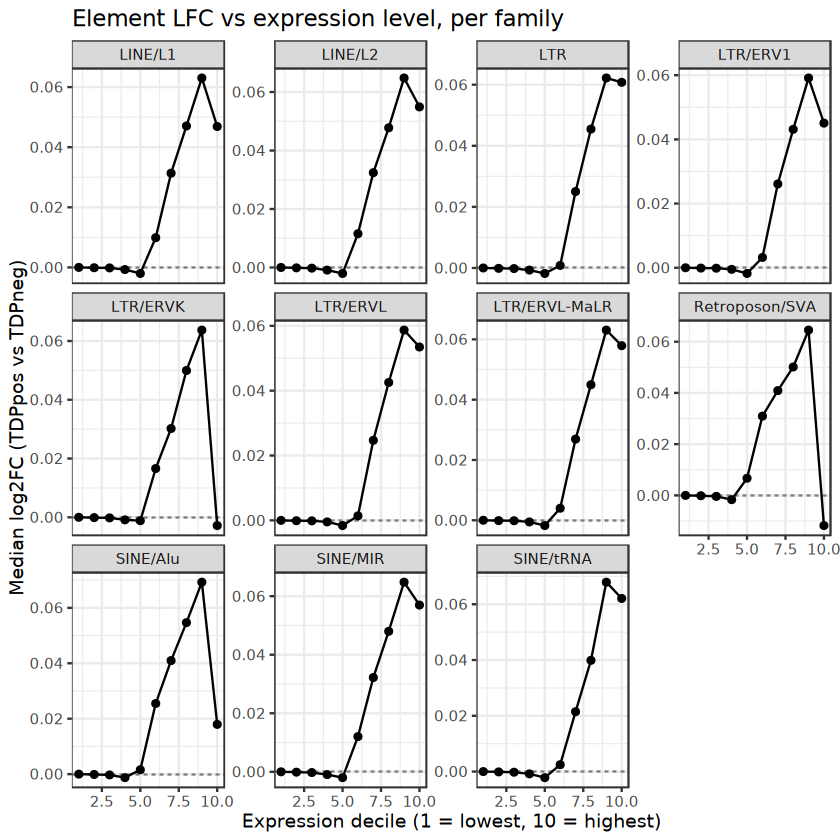

In [38]:
# Median LFC by element expression decile, per family
res_tdp %>%
  filter(class_family %in% target_families,
         !is.na(log2FoldChange), !is.na(baseMean)) %>%
  group_by(class_family) %>%
  mutate(expr_decile = ntile(baseMean, 10)) %>%
  group_by(class_family, expr_decile) %>%
  summarise(
    median_lfc = median(log2FoldChange),
    mean_lfc   = mean(log2FoldChange),
    n          = n(),
    n_de       = sum(padj < 0.05, na.rm = TRUE),
    .groups    = "drop"
  ) %>%
  ggplot(aes(expr_decile, median_lfc)) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "grey50") +
  geom_line() +
  geom_point() +
  facet_wrap(~ class_family, scales = "free_y") +
  theme_bw() +
  labs(x = "Expression decile (1 = lowest, 10 = highest)",
       y = "Median log2FC (TDPpos vs TDPneg)",
       title = "Element LFC vs expression level, per family")

In [39]:
# Plot library size composition: rRNA, mRNA, repeats, intergenic — if available
# If not, at minimum check whether TDPpos samples differ in median percent of
# reads on protein-coding genes vs everything else

# Even simpler: regress size factor on diagnosis and TDP status
sf_check <- pcc_meta %>%
  left_join(tibble(sample_id = colnames(dds), sf = sizeFactors(dds)),
            by = "sample_id")

lm(sf ~ tdp43_status + diagnosis + sex + age_death_num + pmi + rin +
        sequencingBatch + Study,
   data = sf_check) %>%
  broom::tidy() %>%
  print(n = Inf)

# A tibble: 11 × 5
   term                    estimate std.error statistic  p.value
   <chr>                      <dbl>     <dbl>     <dbl>    <dbl>
 1 (Intercept)             1.16       0.138       8.39  5.67e-16
 2 tdp43_statusTDPpos      0.0792     0.0128      6.20  1.26e- 9
 3 diagnosisControl       -0.0411     0.0149     -2.76  5.97e- 3
 4 diagnosisMCI           -0.0571     0.0159     -3.60  3.53e- 4
 5 diagnosisOtherDementia -0.117      0.0461     -2.53  1.17e- 2
 6 sexM                   -0.00156    0.0128     -0.122 9.03e- 1
 7 age_death_num          -0.000894   0.00152    -0.590 5.56e- 1
 8 pmi                    -0.000483   0.00117    -0.414 6.79e- 1
 9 rin                    -0.0110     0.00413    -2.67  7.91e- 3
10 sequencingBatchNYGC3    0.00867    0.0219      0.395 6.93e- 1
11 StudyROS                0.0107     0.0124      0.857 3.92e- 1


## Mean of log2(count+1) per element per sample

In [42]:
fam_robust_list <- list()

for (fam in target_families) {
  safe  <- gsub("/", "_", fam)
  fpath <- file.path(FAMILY_DIR, sprintf("element_long_%s.qs", safe))
  if (!file.exists(fpath)) next

  fam_long <- qread(fpath)

  fam_summary <- fam_long %>%
    group_by(sample_id) %>%
    summarise(
      mean_log2_count    = mean(log2(count + 1)),        # geometric mean of counts
      median_log2_count  = median(log2(count + 1)),
      trimmed_mean_count = mean(count, trim = 0.05),     # 5% trimmed arithmetic mean
      sum_count          = sum(count),                   # the old (dominated) summary
      .groups = "drop"
    ) %>%
    mutate(class_family = fam)

  fam_robust_list[[fam]] <- fam_summary
  rm(fam_long); gc(full = TRUE)
}

In [43]:
fam_robust <- bind_rows(fam_robust_list) %>%
  left_join(pcc_meta %>% select(sample_id, tdp43_status),
            by = "sample_id") %>%
  mutate(class_family = factor(class_family, levels = target_families))

qsave(fam_robust, file.path(OUT_DIR, "fam_robust_summaries.qs"), nthreads = 8)
write_csv(fam_robust, file.path(OUT_DIR, "fam_robust_summaries.csv"))

In [ ]:
p_box <- fam_robust %>%
  ggplot(aes(tdp43_status, mean_log2_count, fill = tdp43_status)) +
  geom_boxplot(outlier.shape = NA, alpha = .6) +
  ggbeeswarm::geom_quasirandom(aes(color = tdp43_status),
                               width = .15, size = .6, alpha = .65) +
  scale_fill_manual(values = c(TDPneg = "#4C72B0", TDPpos = "#C44E52"),
                    guide = "none") +
  ggnewscale::new_scale_color() +
  geom_text(
    data = family_emm_res %>%
      mutate(class_family = factor(class_family, levels = target_families)) %>%
      select(class_family, padj),
    aes(label = sprintf("padj=%.2g", padj), color = padj < 0.05),
    x = -Inf, y = Inf, hjust = 0, vjust = 1, inherit.aes = FALSE
  ) +
  scale_color_manual(values = c(`TRUE` = "firebrick", `FALSE` = "grey20"),
                     guide = "none") +
  ggh4x::facet_wrap2(~ class_family, scales = "free_y", axes = "y", ncol = 4) +
  theme_bw(base_size = 11) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(x = NULL,
       y = "Mean log2(normalized count + 1) per element",
       title = "ROSMAP PCC : repeat expression per element (per family)") +
  coord_cartesian(clip = "off")

ggsave(file.path(PLOTS_DIR, "family_boxplots.pdf"),
       p_geomean_box, width = 12, height = 9)

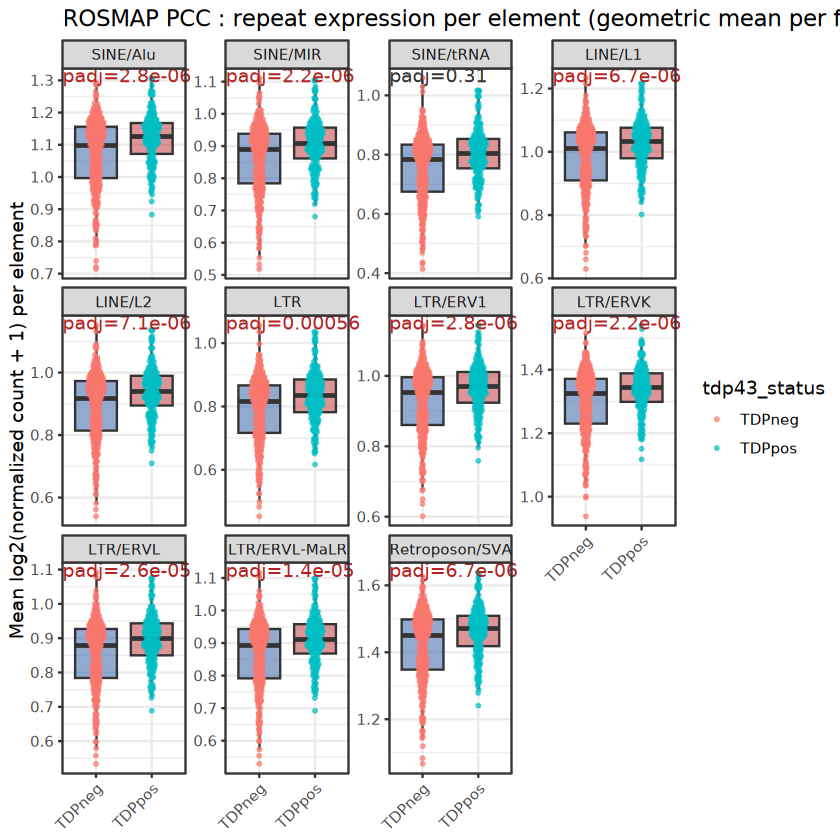

In [48]:
p_box